<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#История-продаж-на-рынке-и-изучение-актуальности-игровых-платформ" data-toc-modified-id="История-продаж-на-рынке-и-изучение-актуальности-игровых-платформ-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>История продаж на рынке и изучение актуальности игровых платформ</a></span></li><li><span><a href="#Изучение-игровых-плафторм-и-выделение-наиболее-перпективных" data-toc-modified-id="Изучение-игровых-плафторм-и-выделение-наиболее-перпективных-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Изучение игровых плафторм и выделение наиболее перпективных</a></span></li><li><span><a href="#Влияние-отзывов-на-продажи" data-toc-modified-id="Влияние-отзывов-на-продажи-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Влияние отзывов на продажи</a></span></li><li><span><a href="#Изучение-игровых-жанров-и-их-влияние-на-продажи" data-toc-modified-id="Изучение-игровых-жанров-и-их-влияние-на-продажи-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Изучение игровых жанров и их влияние на продажи</a></span></li></ul></li><li><span><a href="#Портреты-пользователей-разных-регионов" data-toc-modified-id="Портреты-пользователей-разных-регионов-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Портреты пользователей разных регионов</a></span><ul class="toc-item"><li><span><a href="#NA" data-toc-modified-id="NA-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>NA</a></span></li><li><span><a href="#EU" data-toc-modified-id="EU-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>EU</a></span></li><li><span><a href="#JP" data-toc-modified-id="JP-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>JP</a></span></li></ul></li><li><span><a href="#Проверка-гипотез" data-toc-modified-id="Проверка-гипотез-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Проверка гипотез</a></span><ul class="toc-item"><li><span><a href="#Средние-пользовательские-рейтинги-платформ-Xbox-One-и-PC-одинаковые" data-toc-modified-id="Средние-пользовательские-рейтинги-платформ-Xbox-One-и-PC-одинаковые-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Средние пользовательские рейтинги платформ Xbox One и PC одинаковые</a></span></li><li><span><a href="#Средние-пользовательские-рейтинги-жанров-Action-и-Sports-разные." data-toc-modified-id="Средние-пользовательские-рейтинги-жанров-Action-и-Sports-разные.-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Средние пользовательские рейтинги жанров Action и Sports разные.</a></span></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Вывод</a></span></li></ul></div>

# Исследование мирового рынка компьютерных игр

Заказчик исследования - интернет-магазин, который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Необходимо выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

Импортируем необходимые библиотеки и зададим функцию data_check для базовой оценки данных.

In [4]:
import os
import math
import re
import datetime as dt
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn')

In [5]:
def data_check(df):
    df.info()
    print('Проверка наличия дубликатов:', df.duplicated().sum())
    print('Проверка наличия пропусков:', df.isna().sum().sum())
    display(df.head())

## Загрузка данных

Загрузим данные в таблицу df

In [6]:
pth1 = '-/datasets/games.csv'
pth2 = 'https://-/games.csv'

if np.logical_and(os.path.exists(pth1), os.path.isfile(pth1)):
    df = pd.read_csv(pth1)
elif pth2.endswith('.csv'):
    df = pd.read_csv(pth2)
else:
    print('Файл с данными не найден')

Оценим имеющиеся данные при помощи функци data_check и приведем их описание

In [7]:
data_check(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
Проверка наличия дубликатов: 0
Проверка наличия пропусков: 22318


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Имеется информация о почти 17 тысячах игр в разрезе 11 признаков (6 числовых и 5 категориальных). Все они, кроме полей Year_of_Release и User_Score, имеют соответствующий своему содержанию тип данных. Полные дубликаты отсутсвуют, однако в данных большое количество пропусков - в том или количестве их содержат более половины признаков. Для понимания качества имеющихся данных и дальнейшей тактики работы с пропусками, посмотрим на количесто пропущенных и нулевых значений в колонках с численными типами данных. 

In [8]:
attribute_list = df.columns
columns_name = []
nan_count_list = []
ratio_nan_list = []
zero_count_list = []
for attribute in attribute_list:
    if (df[df[attribute].isna() == True].shape[0]) != 0:
        columns_name.append(attribute)
        nan_count_list.append(df[df[attribute].isna() == True].shape[0])
        ratio_nan_list.append(round(df[df[attribute].isna() == True].shape[0] / df.shape[0] * 100, 2))
        zero_count_list.append(df[df[attribute] == 0].shape[0])
    
zero_attribute_table = pd.DataFrame((nan_count_list, ratio_nan_list, zero_count_list),
                                    index=['NaN_count', 'NaN_ratio', 'zero_count'], columns=columns_name)
zero_attribute_table

,Name,Year_of_Release,Genre,Critic_Score,User_Score,Rating
NaN_count,2.00,269.00,2.00,8578.00,6701.00,6766.00
NaN_ratio,0.01,1.61,0.01,51.32,40.09,40.48
zero_count,0.00,0.00,0.00,0.00,0.00,0.00


Нулевые значения полностью отсутствуют, а атрибуты имеющие пропуски поделились на две части - в первой (name, year_of_release и genre) процент пропусков небольшой, тогда как во второй (critic_score, user_score и	rating) все не так радужно, пропущено более 40% значений.

**Описание данных:**
- name — название игры;
- platform — платформа;
- year_of_release — год выпуска;
- genre — жанр игры;
- na_sales — продажи в Северной Америке (миллионы проданных копий);
- eu_sales — продажи в Европе (миллионы проданных копий);
- jp_sales — продажи в Японии (миллионы проданных копий);
- other_sales — продажи в других странах (миллионы проданных копий);
- critic_score — оценка критиков (максимум 100);
- user_score — оценка пользователей (максимум 10);
- rating — рейтинг от организации ESRB.

## Подготовка данных

Для удобства дальнейшей работы с данными приведем названия столбцов к нижнему регистру.

In [9]:
df.columns = df.columns.str.lower()
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

Далее приведем данные в колонках `year_of_release` и `user_score` к типу int, приведя пользовательские оценки к единой шкале с оценками критиков для удобства анализа. Перед преобразованием данных с годом выпуска игры обработаем пропуски - заменим их нулем. К тому же в названии некоторых игр, например спортивных симуляторов, содержится информация о годе выпуска игры, таким образом возможно уменьшить количество пропущенных значений. Зададим функцию name_year_excretion, которая проверяет наличие в названии четырехзначного числа в диапазоне от 1980 до 2019, и в случае наличия присваиает его колонке с годом выпуска игры. В противном случае присваивается ноль.

In [10]:
def name_year_excretion(row):
    if pd.isna(row['year_of_release']) == True:
        try:
            return int(re.search('(19[8-9]\d)|(20[0-1]\d)', row['name']).group())
        except:
            return 0
    else:
        return row['year_of_release']

In [11]:
#df = df.assign(year_of_release = df.apply(name_year_excretion, axis=1))
df['year_of_release'] = df.apply(name_year_excretion, axis=1)

Проверим корректность работы функции

In [12]:
print(df[df['year_of_release'].isna() == True].shape[0])
df[df['year_of_release'] == 0].shape[0]

0


252

Теперь можем преобразовать тип данных в int при помощи функции astype.

In [13]:
df['year_of_release'] = df['year_of_release'].astype('int')

Продолжим преобразование типов данных, приведем колонку user_score к float. Для начала посмотрим какие значения могут принимать данные в этом поле.

In [14]:
df['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

Помимо пропущенных значений, и числел в диапазоне от 0 до 10 имеется строковое значение tbd. Оно является аббревиатурой от 'To Be Determined', которое означает, что игра не имеет рейтинга либо по причине полного отсутствия оценок, либо по причине их низкого количества, которое не позволяет корректно рассчитать пользовательскую оценку. Замена пропущенных значений расчетными у метрик, связанных с оценками и рейтингами, дает очень низкую точность и сильно искажает полученную в ходе исследования картину. Т.к. каждая игра является уникальным продуктом, на итоговую оценку критиков или игроков влияет огромное количество факторов, помимо тех, которыми мы располагаем в имеющихся данных, соответственно необходимо заменить пропуски и оценки игр с пометкой tbd на какое-либо фиксированное значение. Наиболее логичным кажется вариант с нулем, однако у нас уже имеются игры с таким рейтингом, поэтому изучим такие игры отдельно, чтобы исключить вариант с ошибкой в соответствующем поле.

In [15]:
df.query('user_score == "0"')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
2835,My Little Pony: Pinkie Pie's Party,DS,2008,Adventure,0.66,0.0,0.0,0.06,NaN,0,E


Нулевой рейтинг имеет единственная игра - My Little Pony: Pinkie Pie's Party. Беглый поиск в интернете показал, что ноль в пользовательской оценке является ожидаемо ошибочным, по данным imdb средняя оценка на основании 11 отзывов - 7.9 баллов. Присвоим игре найденную в сети оценку, заменим все пропущенные значения и рейтинг tbd нулем, а также приведем само поле к типу float, после чего умножим на 10 для приведения к стобальной шкале, с последующим преобразованием в int.

In [16]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce').fillna(0)
df.loc[2835, 'user_score'] = 7.9
df['user_score'] = (df['user_score'] * 10).astype('int')

Перейдем к обработке пропусков в других колонка. В жанре и названии игры имеется по два пропуска, скорее всего они относятся к одним и тем же играм. Посмотрим, и если это так, данные строки придется удалить, т.к. во-первых, эти строки без названия и жанра будут полностью бесполезны для анализа, а во-вторых, таким количеством некорректныых данных в объемах предоставленного датасета можно пренебречь.

In [17]:
df[(df['name'].isna()==True)&(df['genre'].isna()==True)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,0,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,0,NaN


Гипотеза подтвердилась, удаляем строки. Далее посчитаем суммарные продажи во всех регионах и запишем их в отдельный столбец `total_sales`.

In [18]:
df = df.dropna(subset=['name'])
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

Необработанными остались пропуски в полях с оценками критиков и рейтингом игр. Аналогично оценам пользователей, такие данные бессмысленно заполнять какими-либо расчетными значениями. Поэтому заменим пропуски в поле critic_score нулями, а в колонке rating и вовсе не будем трогать, т.к. рейтинг имеет строковый тип даннных и никаких математических операций с ним проводиться не будет.

In [19]:
df['critic_score'] = df['critic_score'].fillna(0)

Этап подготовки данных завершен, проверим корректность всех проведенных манипуляций и перейдем к исследованию данных.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16713 non-null  int32  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     16713 non-null  float64
 9   user_score       16713 non-null  int32  
 10  rating           9949 non-null   object 
 11  total_sales      16713 non-null  float64
dtypes: float64(6), int32(2), object(4)
memory usage: 1.5+ MB


## Исследовательский анализ данных

### История продаж на рынке и изучение актуальности игровых платформ

Посмотрим, сколько игр выпускалось в разные годы.

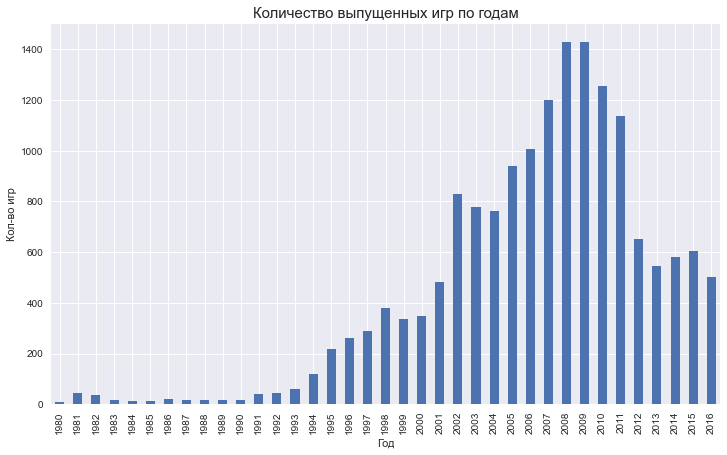

In [21]:
plt.figure(figsize=(12,7))
df.query('year_of_release != 0').groupby('year_of_release')['name'].count().plot(kind='bar')
plt.title('Количество выпущенных игр по годам', fontsize=15)
plt.xlabel('Год')
plt.ylabel('Кол-во игр')
plt.show()

В период с 80 по 90 год количество выпускаеых игр было стабильно небольшим, однако уже с начала 90х начался резкий рост, который вышел на свой пик в 2008-2009 годах, после чего началось снижение. В 2012 году произошел резкий спад количества выпущенных игр (-57%), после которого метрика стабилизировалась на отметке 550-600 штук в год. Возможно такая динамика объясняется резким ростом игрового рынка с середины 90х годов, когда различные игровые консоли и ПК стали более доступны и получили широкое распространение, после чего количество их владельцев, а соответственно и платежеспособный спрос вышли на плато. В этот момент бурно растущий рынок игр продолжил по инерции расти и дальше, однако после некоторого временного лага откорректировался и пришел в равновесие со спросом как на игровые платформы, так и на сами игры. Для проверки этого предположения нужно посмотреть, как менялись продажи по платформам. Выберем платформы с наибольшими суммарными продажами и построим распределение по годам. При этом, учитывая стагнацию рынка и незначительный объем продаж в 80х годах, а также тот факт, что игровая индустрия, как и предпочтения пользователей сильно изменились с тех времен, основной интерес представляют данные о играх выпущенных с начала 90х годов. Проранжруем платформы по суммарным продажам, чтобы выделить наиболее успешные.

In [22]:
platform_total_sales = df.groupby('platform')['total_sales'].agg(['sum', 'count']).sort_values(by='sum', ascending=False).reset_index()
platform_total_sales.columns = ('platform', 'total_sales', 'games_cnt')
platform_total_sales['sales_per_game'] = round(platform_total_sales['total_sales'] / platform_total_sales['games_cnt'], 2)
platform_total_sales[['platform', 'total_sales']]

,platform,total_sales
0,PS2,1255.77
1,X360,971.42
2,PS3,939.65
3,Wii,907.51
4,DS,806.12
5,PS,730.86
6,GBA,317.85
7,PS4,314.14
8,PSP,294.05
9,PC,259.52


В имеющихся данных содержится информация о играх, выпущенных на 31 платформе, суммарные продажи которых могут отличаться на несколько порядков. По размеру продаж видно, что явно лидируют 6 платформ, продажи остальных существенно ниже, поэтому построим графики годовых продаж именно по ним. При первичном построении графиков на графике платформы DS было обнаружено аномальное растяжение оси X (год выпуска), причиной которого была одна игра с некорректно указаным годом выпуска. Поэтому перед постройкой графиков необходимо выявить эту игру и исправить год выпуска на корректный.

In [23]:
display(df.query('platform == "DS" and year_of_release < 2001 and year_of_release != 0'))
df.loc[15957, 'year_of_release'] = 2010

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
15957,Strongest Tokyo University Shogi DS,DS,1985,Action,0.0,0.0,0.02,0.0,0.0,0,NaN,0.02


Теперь можно строить графики

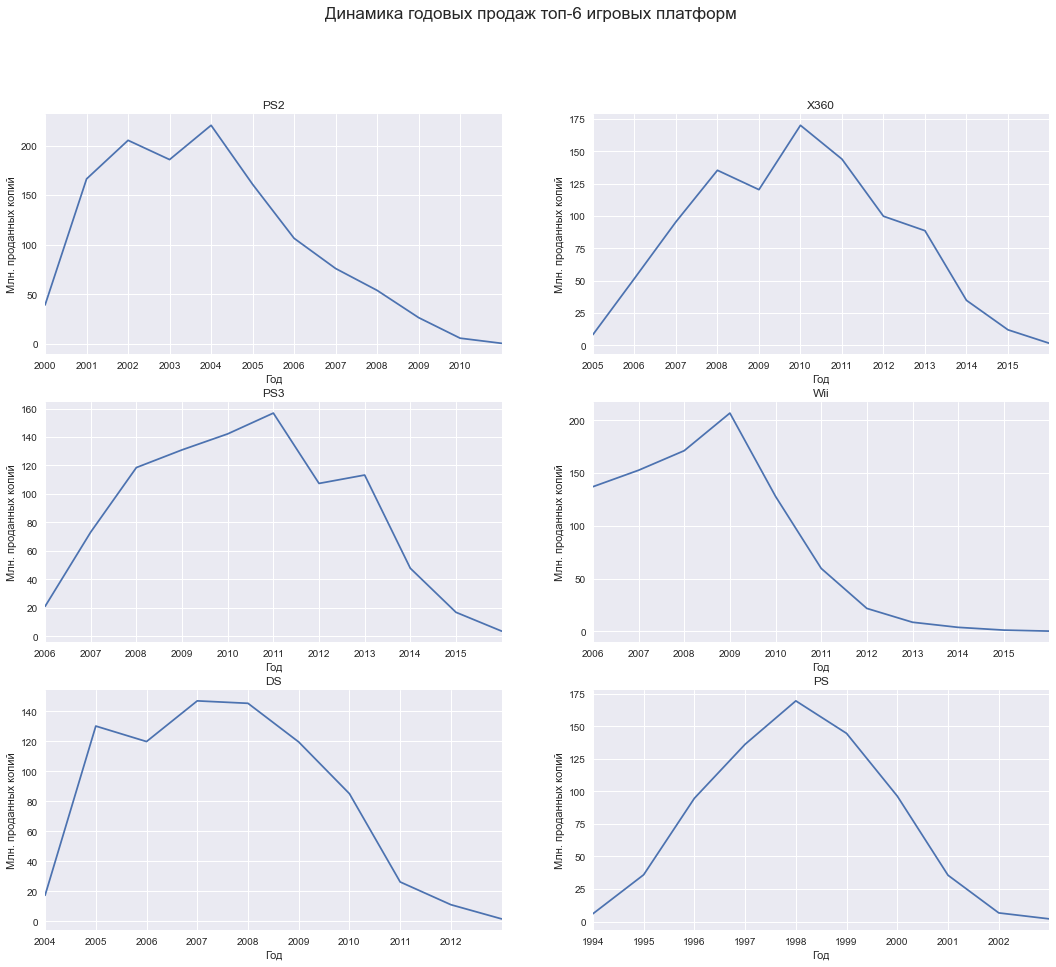

In [24]:
fig_sup, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 15))
axs = axes.ravel()
plt.suptitle('Динамика годовых продаж топ-6 игровых платформ', fontsize=17)
plt.xlabel('Год')
plt.ylabel('Кол-во игр')
fig_counter = 0
for platform in platform_total_sales.head(6)['platform'].values:
    df[(df['year_of_release'] != 0) & (df['platform'] == platform)].groupby('year_of_release')['total_sales'].sum(
    ).plot(title=platform, xlabel='Год', ylabel='Млн. проданных копий', ax=axs[fig_counter])
    x_lim_min = df[(df['year_of_release'] != 0) & (df['platform'] == platform)]['year_of_release'].min()
    x_lim_max = df[df['platform'] == platform]['year_of_release'].max()
    axs[fig_counter].set_xlim(x_lim_min, x_lim_max)
    axs[fig_counter].set_xticks(range(x_lim_min, x_lim_max, 1))
    fig_counter += 1

По графикам видно, что средний срок жизни игровой платформы около 10 лет. Динамика продаж не имеет какого-то общего для всех платформ паттерна - продажи могут плавно увеличиваться с очень низкого уровня (PS), так и стартовать сразу с очень высоких отметок (Wii). Общее лишь одно - вторая половина срока активного существования платформы всегда приходится на нисходящий тренд продаж, пик приходится либо на первую треть, либо на половину временного интервала. Однако можно ли экстраполировать эту тенденцию на все платформы? Выведем срок активного существования каждой платформы в годах. При расчете необходимых статистик платформы анонсированные после 2011 года можно не учитывать - на момент актуальности используемых данных они скорее всего находятся в стадии активного существования и учитывать их показатели в оценке среднего и медианного срока жизни платформы некорректно.

In [25]:
platform_lifetime = df.query('year_of_release != 0').groupby('platform')['year_of_release'].agg(['min', 'max'])
platform_lifetime['lifetime'] = platform_lifetime['max'] - platform_lifetime['min']
platform_lifetime = platform_lifetime.sort_values(by='min').reset_index()
display(platform_lifetime)
platform_lifetime[platform_lifetime['min'] < 2011]['lifetime'].agg(['mean', 'median']).round(2)

,platform,min,max,lifetime
0,2600,1980,1989,9
1,NES,1983,1994,11
2,PC,1985,2016,31
3,GB,1988,2001,13
4,SNES,1990,1999,9
5,GEN,1990,1994,4
6,GG,1992,1992,0
7,SCD,1993,1994,1
8,NG,1993,1996,3
9,SAT,1994,1999,5


mean      7.58
median    8.50
Name: lifetime, dtype: float64

В целом срок около 10 лет характерен скорее для коммерчески успешных платформ, что логично. Менее успешные держатся на рынке по разному, каждый случай уникален, однако средний срок по выборке не сильно меньше - около 8 лет. Дополнительно можно выделить две платформы-долгожителя: PC и GB. И если с ПК все понятно (постоянно развивающаяся многофунциональная модульная платформа), то секрет Game Boy прост - фактически под этим названием объединено несколько поколений последовательно улучшавшихся игровых консолей. Для последующего анализа будет оправдано избавиться от данных об играх, созданных для явно неактуальных платформ. Если брать за отправную точку 2016 год и учесть 8-10 лет срок активного существования, целесообразно отсечь все платформы, у которых последние из анонсированных игр близки к заданному горизонту анализа. В нашем случае стоит остановиться на платформе DS, т.к. у стоящей перед ней в хоронологичнском порядке консоли GS последняя их игр вышла в 2007 году. На еще более старой PS2 игры выходили до 2011 года включительно, к тому же это платформа с максимальными продажами, поэтому её исключать не будем. Таким образом отсекаем все игры, выпущенные для платформ на которых последняя игра вышла ранее 2010 года, и записываем в таблицу game_filtered.

In [26]:
game_filtered = df[df['platform'].isin(list(platform_lifetime[platform_lifetime['max'] >= 2010]['platform']))]
print('Количество оставшихся игр -', game_filtered.shape[0])
print('Количество оставшихся платформ -', game_filtered['platform'].nunique())

Количество оставшихся игр - 12144
Количество оставшихся платформ - 12


Из 16713 игр осталось 12144, т.е. сохранилось более 70% исходной информации, при том, что из 31 платформы осталось лишь 12. Посмотрим какие платформы лидируют по продажам. Однако сравнивать продажи напрямую будет некорректно - некоторые платформы уже закончили свой жизненный цикл, а какие-то еще активны и их продажи очевидно будут расти. Поэтому сравнивать популярность платформ между собой будем по среднему количеству выпущенных игр в год.

### Изучение игровых плафторм и выделение наиболее перпективных

In [27]:
info_about_actual_platforms = platform_total_sales[platform_total_sales['platform'].isin(
    list(platform_lifetime[platform_lifetime['max'] >= 2010]['platform']))].merge(
    platform_lifetime[['platform', 'min', 'max']], on='platform', how='left')
info_about_actual_platforms['sales_per_year'] = round(info_about_actual_platforms['total_sales'] / (
    info_about_actual_platforms['max'] - info_about_actual_platforms['min']), 2)
info_about_actual_platforms = info_about_actual_platforms.rename({'min':'start_year', 'max':'last_games'}, axis=1)
info_about_actual_platforms[['platform', 'total_sales', 'games_cnt', 'sales_per_game', 'sales_per_year', 'start_year', 'last_games']].sort_values(
    by='sales_per_year', ascending=False).reset_index(drop=True)

,platform,total_sales,games_cnt,sales_per_game,sales_per_year,start_year,last_games
0,PS2,1255.77,2161,0.58,114.16,2000,2011
1,PS4,314.14,392,0.80,104.71,2013,2016
2,PS3,939.65,1331,0.71,93.96,2006,2016
3,Wii,907.51,1320,0.69,90.75,2006,2016
4,DS,806.12,2151,0.37,89.57,2004,2013
5,X360,971.42,1262,0.77,88.31,2005,2016
6,XOne,159.32,247,0.65,53.11,2013,2016
7,3DS,259.00,520,0.50,51.80,2011,2016
8,PSP,294.05,1209,0.24,26.73,2004,2015
9,WiiU,82.19,147,0.56,20.55,2012,2016


Всю первую тройку занимают консоли Sony, причем как по общим продажам, так и по продажам за год лидирует самая старая из представленных платформ - PS2. Также стоит отметить, что по мере развития платформы PS, игры на них в среднем становятся более продаваемые - последовательно растут продажи на игру. Их основные конкуренты от Microsoft находятся на 5 и 6 строчках. Большинство платформ еще активны - на момент 2016 года игры перестали выходить всего на трех. Какой у каждой платформы тренд выручки, восходящий или нисходящий, по этим данным можно лишь предположить - с высокой вероятностью, растут те платформы, которые находятся в первой половине своего жизненного цикла. Например, у популярной PS4, стартовавшей в 2013 году продажи скорее всего растут, тогда как у PS3, отметившей в 16 году десятилетний юбилей, наоборот падают. Для проверки построим график динамики выручки всех актуальных платформ начиная с 2013 года. Во-первых, данных за последние 4 года вполне достаточно для определения тренда, во-вторых, так мы захватим все актуальные платформы, т.к. самые новые относятся к 2013 году.

platform,3DS,PC,PS3,PS4,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,
2013,56.57,12.73,113.25,25.99,10.59,8.59,21.65,88.58,18.96
2014,43.76,13.28,47.76,100.00,11.90,3.75,22.03,34.74,54.07
2015,27.78,8.52,16.82,118.90,6.25,1.14,16.35,11.96,60.14
2016,15.14,5.25,3.60,69.25,4.25,0.18,4.60,1.52,26.15


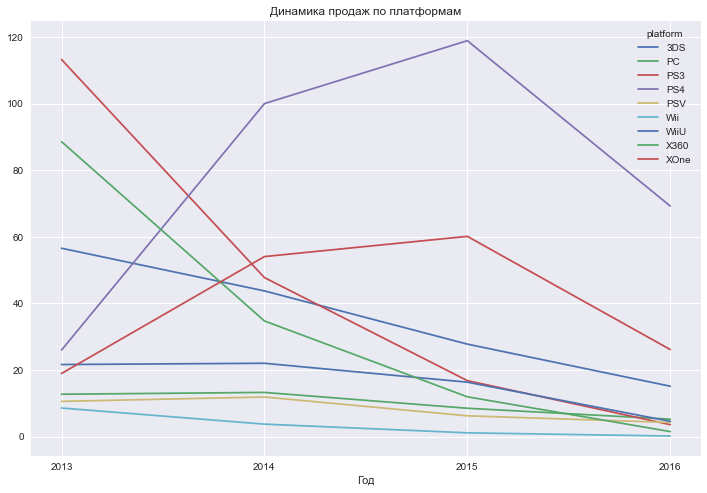

In [28]:
actual_games = df.query('year_of_release >= 2013')

display(actual_games.pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').dropna(axis=1))
ax = actual_games.pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').dropna(axis=1).plot(
    figsize=(12, 8), xlabel='Год', title='Динамика продаж по платформам')
ax.set_xticks(range(2013, 2017, 1))
plt.show()

2016 трудный для индустрии год - все платформы без исключения показывают падение продаж. Однако корреляция с актуальносью платформы все же есть, старые платформы показывают гораздо более сильное падение, по сравнение с более новыми. Наиболее перспективно выглядят PS4 и XOne, это новые и одновременно популярные платформы, относящиеся к постоянно актуализируемым линейкам игровых консолей с огромной базой лояльных пользователей. По крайней мере это единственные платформы, показывающие высокую динамику роста перед провальным 2016 годом. Так же со счетов не стоит сбрасывать 3DS, WiiU и ПК - первые две это свежие модели популярных консолей, а ПК это традиционная широко распространенная игровая платформа, со своими экслюзивами и костяком пользователей. Таким образом мы выделили пять наиболее перспективных с точки зрения продаж игровых платформ (в порядке убывания): **PS4, XOne, 3DS, PC и WiiU**. Запишем их в переменную target_platform.

Посмотрим как выглядит распределение продаж игр на этих платформах. Для этого построим график «ящик с усами» по глобальным продажам. Однако перед этим стоит оценить глобальное распределение для отсечения самых больших выбросов и выбора читаемого масштаба графика - скорее всего самые популярные игры настолько превосходят по продажам типовые, что график построенный без фильтрации выбросов будет неинформативен.

In [29]:
target_platform = ['PS4', 'XOne', '3DS', 'PC', 'WiiU']
df.query('platform == @target_platform')['total_sales'].describe(percentiles=(.25, .75, .95, .99))

count    2280.000000
mean        0.471127
std         1.154924
min         0.010000
25%         0.030000
50%         0.100000
75%         0.370000
95%         2.190500
99%         5.287300
max        14.630000
Name: total_sales, dtype: float64

Максимальное значение по выборке практически втрое превышает 99% перцентиль, а он, в свою очередь, в 11 раз выше среднего значения. Установим ограничение на отрисовку графика по оси Х по 95% перцентилю.

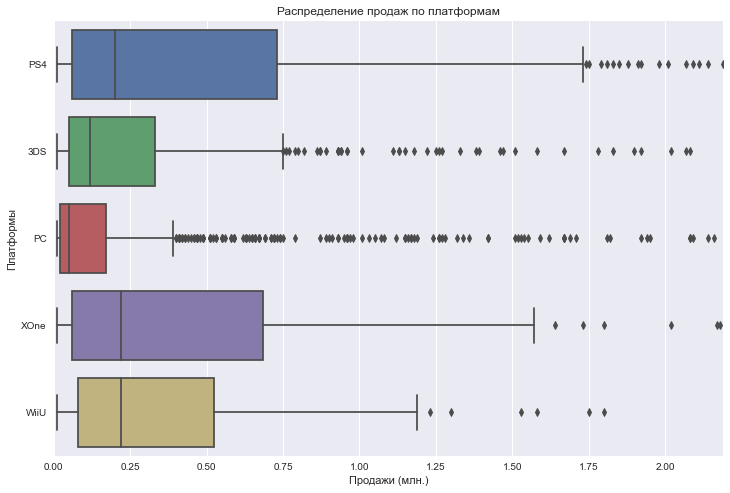

In [30]:
plt.figure(figsize=(12,8))
fig = sns.boxplot(data=df.query('platform == @target_platform'), x='total_sales', y='platform')
fig.set(xlabel='Продажи (млн.)', ylabel='Платформы', title='Распределение продаж по платформам', xlim=([0, 
        np.percentile(df.query('platform == @target_platform')['total_sales'], 95)]))
plt.show()

Хорошо видна как тройка лидеров - PS4, XOne и WiiU, так и аутсайдер - PC. Что характерно, медианы топ-3 практически одинаковые (около 200 тыс.) и выше межквартильного размаха PC. У PC обращает на себя внимание очень плотный хвост из выбросов - популярные игры на этой платформе есть, и их довольно много, но общую статистику продаж тянет на дно большое количество посредственных плохо продающихся продуктов. PS4 явно доминирует, её третий квартиль практически покрывает диапазон нормальных значений продаж 3DS. WiiU отличается очень стабильными продажами своих игр - плотный межквартильный размах, минимальное количество выбросов, при этом первый квартиль самый высокий из всех платформ, а значит доля откровенно плохо продающихся игр на этой платформе минимальная.

### Влияние отзывов на продажи

Посмотрим, как влияют на продажи отзывы пользователей и критиков. Для примера возьмем X360 - это первая по абсолютным продажам платформа, среди сохраняющих на 2016 год актуальность. Для этого построим диаграммы рассеяния и посчитаем корреляцию между отзывами и продажами, заодно посмотрим хорошо ли коррелируют между собой оценки пользователей и критиков.

Корреляция между оценками критиков и продажами игр на X360: 0.394


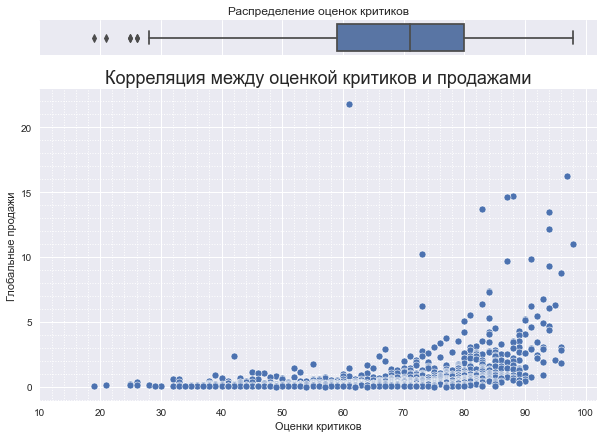

In [31]:
fig, (ax_box, ax_sp) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (.1, .9)}, figsize=(10, 7))
sns.boxplot(x=df.query('platform == "X360" and critic_score != 0')['critic_score'], ax=ax_box)
sns.scatterplot(data=df.query('platform == "X360" and critic_score != 0'), x='critic_score', y='total_sales', ax=ax_sp)
ax_box.set(xlabel='', title='Распределение оценок критиков')
plt.title(label='Корреляция между оценкой критиков и продажами', fontsize=18)
ax_sp.set(xlabel='Оценки критиков', ylabel='Глобальные продажи')
ax_sp.set_xticks(range(10, 101, 10))
plt.minorticks_on()
plt.grid(which='minor', linestyle=':')
print('Корреляция между оценками критиков и продажами игр на X360:',
      df.query('platform == "X360" and critic_score != 0')['critic_score'].corr(
    df.query('platform == "X360" and critic_score != 0')['total_sales']).round(3))

Коэффициент корреляции достаточно низкий, однако определенную зависимость выделить можно: игр с высокими продажами и низкими оценками критиков не бывает. Основная масса игр продается довольно скромными тиражами, большинство точек кучно вытянуты вдоль оси Х, и у таких продажи от оценки критиков зависят слабо, но ближе к концу оси Х точки начинают подниматься вверх, в сторону высоких продаж, особенно это заметно в диапазоне более 80 баллов. Если же не считать единичных исключений, о хороших продажах можно говорить, только если оценка критиков будет выше медианной (хотя игра с максимальными на платформе продажами получила оценку критиков ниже медианной, близко к уровню 1 квартиля). 

Теперь посмотрим на корреляцию с оценкой игроков.

Корреляция между оценками игроков и продажами игр на X360: 0.114


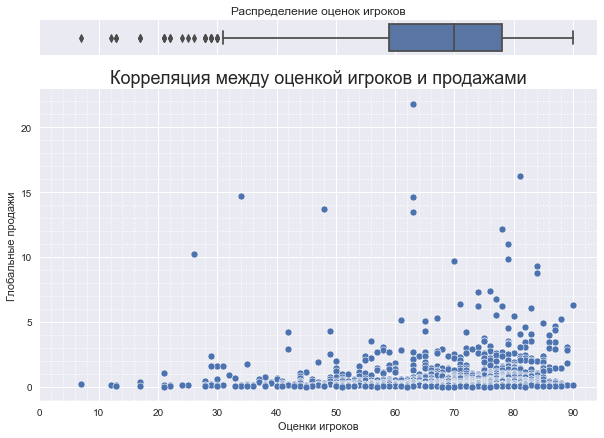

In [32]:
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (.1, .9)}, figsize=(10, 7))
sns.boxplot(x=df.query('platform == "X360" and user_score != 0')['user_score'], ax=ax_box)
sns.scatterplot(data=df.query('platform == "X360" and user_score != 0'), x='user_score', y='total_sales', ax=ax_hist)
ax_box.set(xlabel='', title='Распределение оценок игроков')
plt.title(label='Корреляция между оценкой игроков и продажами', fontsize=18)
ax_hist.set(xlabel='Оценки игроков', ylabel='Глобальные продажи')
ax_hist.set_xticks(range(0, 95, 10))
plt.minorticks_on()
plt.grid(which='minor', linestyle=':')
print('Корреляция между оценками игроков и продажами игр на X360:', 
      df.query('platform == "X360" and user_score != 0')['user_score'].corr(
    df.query('platform == "X360" and user_score != 0')['total_sales']).round(3))

Коэффициент корреляции совсем низкий, при этом аналогичной оценке критиков зависимости факта высоких продаж с преодолением медианного порога балла оценки у оценок пользователей нет. Игры с достаточно высокими продажами могут выходить не то, что за межквартильный размах, но даже определяться как выбросы. Впрочем концептуально распределение схоже с предыдущим - практичеки такая же медиана, большинство игр имеют низкие продажи и растянуты вдоль оси Х, хотя хвост с низкими оценками более разряженный, у игроков оценки игр более сконцентрированы в зоне 50+ баллов.

Наконец посмотрим как коррелируют между собой оценки критиков и игроков.

Коэффициент корреляции между оценками критиков и игроков: 0.618


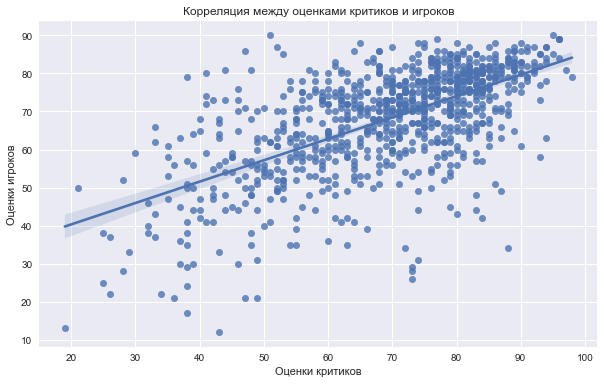

In [33]:
plt.figure(figsize=(10,6))
ax = sns.regplot(data=df.query('platform == "X360" and critic_score != 0 and user_score != 0'),
                x='critic_score', y='user_score')
ax.set(xlabel='Оценки критиков', ylabel='Оценки игроков', title='Корреляция между оценками критиков и игроков')
print('Коэффициент корреляции между оценками критиков и игроков:', df.query('platform == "X360" and critic_score != 0 and user_score != 0')['critic_score'].corr(
    df.query('platform == "X360" and critic_score != 0 and user_score != 0')['user_score']).round(3))

Корреляция между оценками умеренная - хотя основная масса оценок отличается не слишком сильно, достаточно много примеров практически диаметрально противоположных оценок. В качестве вывода можно сказать, что для прогнозирования продаж игры надежнее ориентироваться на оценку критиков, нежели игроков, причем их оценки хотя и имеют ощутимую положительную корреляцию, совпадают далеко не всегда. Однако это справедливо для конкретной платформы. Стоит посмотреть несколько других как популярных, так и не очень платформ чтобы понять, униврсально ли это правило. Для этого зададим функцию `sales_score_corr`, строяющую аналогичные графики распределения и расчитывающую коэффициенты корреляции для заданной платформы.

In [34]:
def sales_score_corr(data, platform_list):
    for platform in platform_list:
        fig_sup, axes = plt.subplots(nrows=2, ncols=2, figsize=(17, 7),
                                    gridspec_kw={'width_ratios': (.5, .5), 'height_ratios': (.1, .9)})
        plt.suptitle('{}'.format(platform), fontsize=17)
        axs = axes.ravel()
        sns.boxplot(x=data.query('platform == @platform and critic_score != 0')['critic_score'], ax=axs[0])
        sns.scatterplot(data=data.query('platform == @platform and critic_score != 0'),
                        x='critic_score', y='total_sales', ax=axs[2])
        axs[0].set(xlabel='', title='Распределение оценок критиков')
        axs[2].set_title(label='Корреляция между оценкой критиков и продажами', fontdict={'fontsize': 14})
        axs[2].set(xlabel='Оценки критиков', ylabel='Глобальные продажи')
        axs[2].set_xticks(range(0, 101, 10))
        plt.minorticks_on()
        plt.grid(which='minor', linestyle=':')
        
        sns.boxplot(x=df.query('platform == @platform and user_score != 0')['user_score'], ax=axs[1])
        sns.scatterplot(data=df.query('platform == @platform and user_score != 0'),
                        x='user_score', y='total_sales', ax=axs[3])
        axs[1].set(xlabel='', title='Распределение оценок игроков')
        axs[3].set_title(label='Корреляция между оценкой игроков и продажами', fontdict={'fontsize': 14})
        axs[3].set(xlabel='Оценки игроков', ylabel='Глобальные продажи')
        axs[3].set_xticks(range(0, 101, 10))
        plt.minorticks_on()
        plt.grid(which='minor', linestyle=':')
        plt.show()
        
        print('Корреляция между оценками игроков и продажами игр на {}:'.format(platform), 
          df.query('platform == @platform and user_score != 0')['user_score'].corr(
        df.query('platform == @platform and user_score != 0')['total_sales']).round(3))
        print('Корреляция между оценками критиков и продажами игр на {}:'.format(platform),
          data.query('platform == @platform and critic_score != 0')['critic_score'].corr(
        data.query('platform == @platform and critic_score != 0')['total_sales']).round(3))
        print('Коэффициент корреляции между оценками критиков и игроков на {}:'.format(platform), df.query(
            'platform == @platform and critic_score != 0 and user_score != 0')['critic_score'].corr(
        df.query('platform == @platform and critic_score != 0 and user_score != 0')['user_score']).round(3))

Передадим функции ранее созданный список наиболее перспективных с точки зрения продаж платформ `target_platform`.

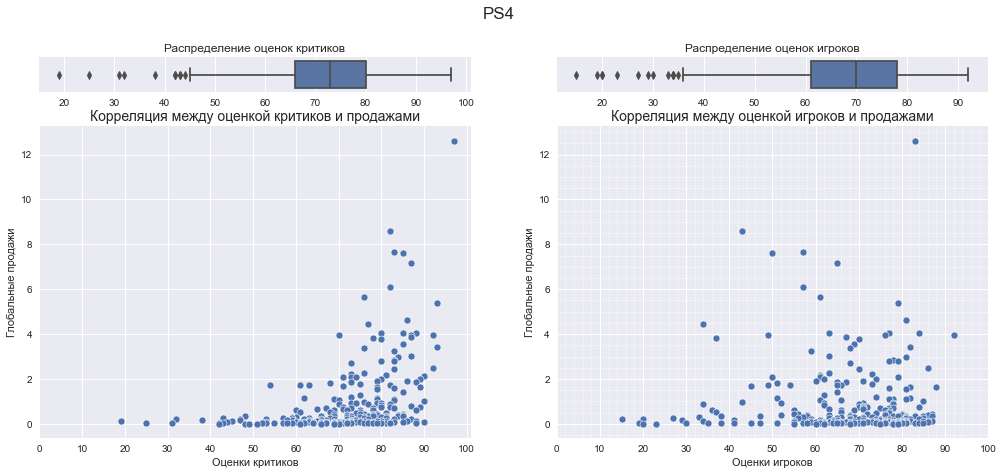

Корреляция между оценками игроков и продажами игр на PS4: -0.032
Корреляция между оценками критиков и продажами игр на PS4: 0.407
Коэффициент корреляции между оценками критиков и игроков на PS4: 0.558


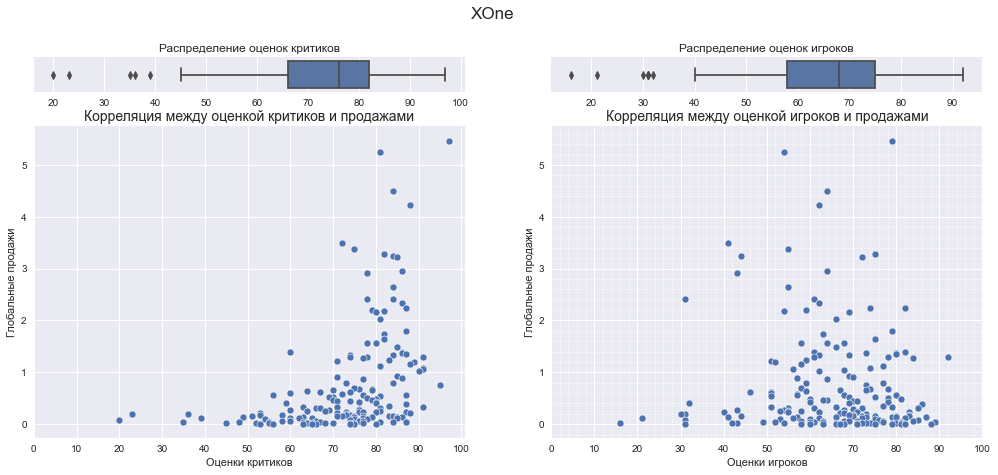

Корреляция между оценками игроков и продажами игр на XOne: -0.069
Корреляция между оценками критиков и продажами игр на XOne: 0.417
Коэффициент корреляции между оценками критиков и игроков на XOne: 0.472


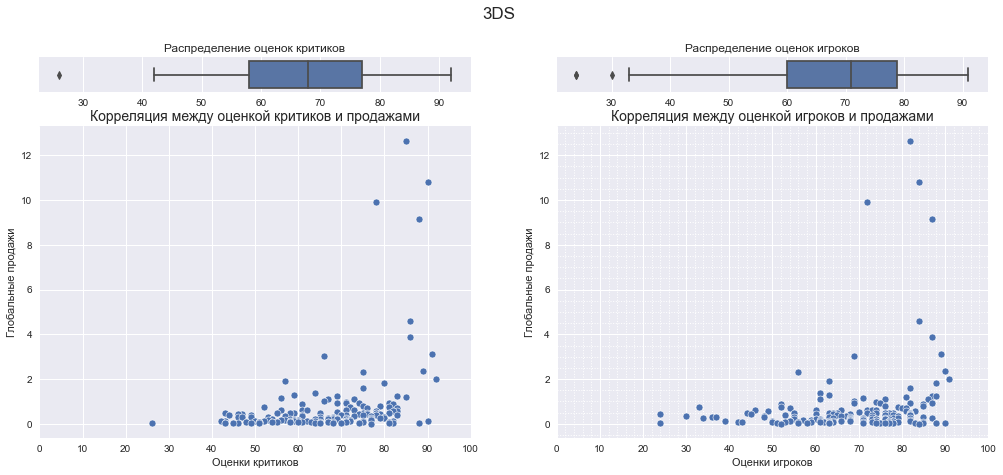

Корреляция между оценками игроков и продажами игр на 3DS: 0.225
Корреляция между оценками критиков и продажами игр на 3DS: 0.349
Коэффициент корреляции между оценками критиков и игроков на 3DS: 0.744


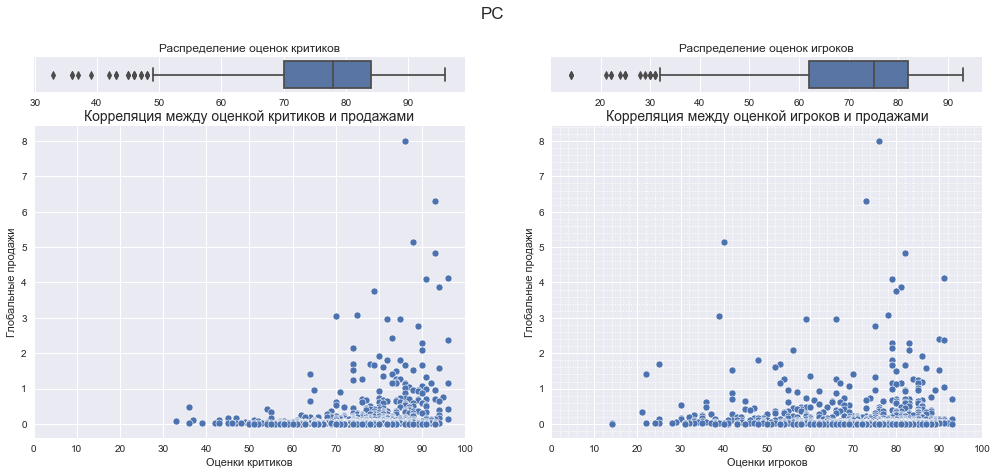

Корреляция между оценками игроков и продажами игр на PC: 0.01
Корреляция между оценками критиков и продажами игр на PC: 0.257
Коэффициент корреляции между оценками критиков и игроков на PC: 0.558


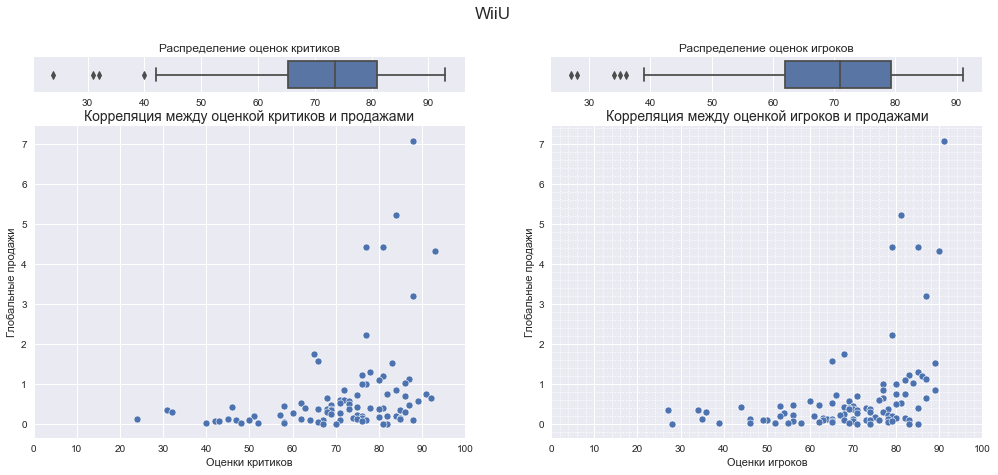

Корреляция между оценками игроков и продажами игр на WiiU: 0.4
Корреляция между оценками критиков и продажами игр на WiiU: 0.348
Коэффициент корреляции между оценками критиков и игроков на WiiU: 0.77


In [35]:
sales_score_corr(df, target_platform)

В целом предположение подтвердилось - оценки критиков коррелируют с продажами лучше, нежели оценки игроков, игры с высокими продажами смещены вправо (область с высокими оценками) сильнее именно на графиках оценок критиков. Также критики, как комично это не звучит, менее критичны - количество игр с очень низкими оценками у игроков значительно выше, это видно и по диапазону нормальных значений на диаграмме размаха, оценки, определяемые как выбросы, у критиков начинаются примерно на 10 баллов больше, чем у игроков. Однако это правило не абсолютно, попадаются платформы, которые ему не соответствуют, например WiiU: она отличается очень высокой корреляцией оценок между собой, их распределение на диаграмме размаха практически одинаковое, а коэффициент корреляции у оценок игроков даже немного более высокий, чем у оценок критиков. Однако решение ориентироваться на оценки критиков универсально, т.к. будет работать и в этом случае, примеров же платформ, когда явно лучше ориентироваться на оценки игроков, не нашлось.

### Изучение игровых жанров и их влияние на продажи

Теперь посмотрим на общее распределение игр по жанрам, а также их влияние на продажи. Для этого найдем общее количество выпущенных в интересующий нас период игр, их суммарные продажи, а также количество проданных копий на 1 игру (sales_per_game) в разрезе по жанрам.

In [36]:
genre_info = game_filtered.groupby('genre').agg({'name': 'count', 'total_sales': 'sum'}).rename({'name': 'game_count'}, axis=1)
genre_info['sales_per_game'] = round(genre_info['total_sales'] / genre_info['game_count'], 2)
display(genre_info.sort_values(by='sales_per_game', ascending=False))
print('Средние продажи на 1 игру, млн.копий:', round(genre_info['sales_per_game'].mean(), 2))
print('Среднее количество игр по жанрам, шт.:', genre_info['game_count'].mean())

,game_count,total_sales,sales_per_game
genre,,,
Shooter,914,839.36,0.92
Platform,432,361.15,0.84
Sports,1564,1014.92,0.65
Racing,760,477.28,0.63
Role-Playing,1158,612.45,0.53
Fighting,509,264.17,0.52
Action,2650,1364.32,0.51
Misc,1414,657.28,0.46
Simulation,725,321.50,0.44


Средние продажи на 1 игру, млн.копий: 0.51
Среднее количество игр по жанрам, шт.: 1012.0


Абсолютными лидерами по коммерческой успешности являются шутеры и платформеры, при этом они выпускаются в количестве ниже среднего показателя по жанрам. Интересно смотрится жанр спортивных игр, находясь на втором месте как по количеству игр, так и по проданным копиям, он замыкает топ-3 продаж на игру. Самый распространенный и успешный жанр, экшены, продается средне, в буквальном смысле. Плохо смотрятся стратегии и пазлы - малое количество игр соответствует низким продажам, примерно вдвое ниже среднего.

Проверим имеются ли значимые различия в продажах игр по жанрам у ранее выделенных платформ (target_platform). При этом ограничим выборку только новыми играми, не старше 5 лет - в выборке имеются игры для PC выходившие с 1985 года, тогда как остальные платформы являютя актуальными платформами, и это может исказить итоговую картину.

In [37]:
genre_info_tp = df.query('platform == @target_platform and year_of_release > 2010').groupby('genre').agg(
    {'name': 'count', 'total_sales': 'sum'}).rename({'name': 'game_count'}, axis=1)
genre_info_tp['sales_per_game'] = round(genre_info_tp['total_sales'] / genre_info_tp['game_count'], 2)
genre_info_tp = genre_info_tp.sort_values(by='sales_per_game', ascending=False)
genre_info_tp = genre_info_tp.merge(genre_info['sales_per_game'].to_frame(), left_index = True, right_index = True, suffixes=(None, '_old'))
genre_info_tp['change_in_sales'] = genre_info_tp['sales_per_game'] - genre_info_tp['sales_per_game_old']
display(genre_info_tp.drop('sales_per_game_old', axis=1))
print('Средние продажи на 1 игру, млн.копий:', round(genre_info_tp['sales_per_game'].mean(), 2))
print('Среднее количество игр по жанрам, шт.:', round(genre_info_tp['game_count'].mean(), 1))

,game_count,total_sales,sales_per_game,change_in_sales
genre,,,,
Shooter,157,179.04,1.14,0.22
Platform,68,63.00,0.93,0.09
Role-Playing,199,149.31,0.75,0.22
Sports,141,97.27,0.69,0.04
Fighting,47,28.05,0.60,0.08
Racing,81,46.83,0.58,-0.05
Simulation,83,41.18,0.50,0.06
Action,569,230.21,0.40,-0.11
Misc,122,39.84,0.33,-0.13


Средние продажи на 1 игру, млн.копий: 0.54
Среднее количество игр по жанрам, шт.: 140.7


Во-первых, незначительно выросли средние продажи, т.к. несмотря на то, что выбранный временной промежуток находится на нисходящем глобальном тренде продаж, мы учитываем только наиболее популярные платформы. Во-вторых, без принципиального изменения популярности жанров, увеличился разброс продаж между ними - у наиболее популярных жанров они увеличились, у наименее упали. Обращается на себя внимание укрепление позиций RPG, жанр поднялся на 3 место , увеличив средние продажи практически в 1,5 раза. Action, несмотря на сохранение абсолютного лидерства по количеству выпущенных игр, серьезно утратил свои позиции по продажам - если раньше они соответствовали средним по индустрии, по актуализированной выборке они стали значительно ниже среднего. Посмотрим на распределение продаж жанров более детально при помощи графика "ящик с усами".

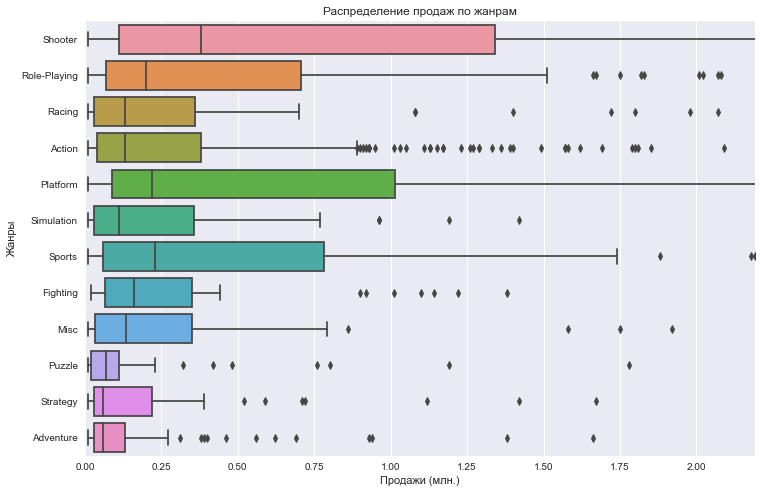

In [38]:
plt.figure(figsize=(12,8))
fig = sns.boxplot(data=df.query('platform == @target_platform and year_of_release > 2010'), x='total_sales', y='genre')
fig.set(xlabel='Продажи (млн.)', ylabel='Жанры', title='Распределение продаж по жанрам', xlim=([0, 
        np.percentile(df.query('platform == @target_platform ')['total_sales'], 95)]))
plt.show()

График позволил выделить несколько дополнительных любопытных деталей. Во-первых, хотя у жанра Sports меньше все рассмотренные метрики (кол-во выпущенных игр, суммарные продажи и продажи на игру) по сравнению с RPG, у него выше как медиана и третий квартиль, так и общий диапазон нормальных значений. Это говорит о том, что продажи спортивных игр распределны более равномерно, такие игры покупают стабильнее, а соответственно и вложения в их продажи в среднем будут немного менее рискованы. Во-вторых, жанр Action характеризуется большим количеством выбросов, соответственно не стоит сбрасывать сам жанр со счетов, просто нужно тчательно подбирать продвигаемые в нем игры.

## Портреты пользователей разных регионов

Составим портрет пользователя каждого региона (NA, EU, JP). Для этого изучим по каждому самые популярные платформы и жанры (топ-5), а также оценим, влияет ли рейтинг ESRB на продажи.

Напишем функцию `region_sales_visualisation`, которая принимает название исследуемого региона, а также колонку с продажами игр по нему, и строитс строит следующие графики:
- столбчатую диаграмму с топ-5 платформ по выручке с выделением не вошедших в топ платформ в категорию other, подписывает каждый столбец относительной долей рынка для каждой платфомы и отрисовывает линию средних продаж по выделенному топ-5 платформ;
- столбчатую диаграмму с топ-5 жанров по выручке с выделением не вошедших в топ жанров в категорию other, подписывает каждый столбец относительной долей рынка для каждого жанра и отрисовывает линию средних продаж по выделенному топ-5 жанров;
- столбчатую диаграмму рейтингов игр по выручке, подписывает каждый столбец относительной долей каждого рейтинга и отрисовывает линию средних продаж по рейтингам.

Т.к. используемая таблица game_filtered хотя и отсекает явно неактуальные платформы, данные в ней содержат информацию о большом количестве старых игр, что в свете сформулированных целей исследования (планирование на очередной год) может искажать получаемые выводы, особенно при анализе популярности платформ. Поэтому графики будут отрисовываться парно: левый - на основании данных из таблицы `game_filtered`, правый - по таблице `actual_games`, на основании игр, выпущенных за последние 4 года (на дату актуальности предоставленных для анализа данных), т.е. с 2013 по 2016 годы включительно.

In [39]:
def region_sales_visualisation(region_col, region_name):
# задание функции для построения графиков
    def graph_func(data_all, data_actual, attribute, att_name, x_lab):
        fig_sup, axs = plt.subplots(nrows=1, ncols=2, figsize=(17, 6), gridspec_kw={'width_ratios': (.5, .5)})
        plt.suptitle(f'Распределение продаж по {att_name} в регионе {region_name}', x=0.57, y=.98, horizontalalignment='right', fontsize = 17)
    
        data_all.sort_values(by=region_col).plot(kind='bar', x=attribute, y=region_col, 
                                                 xlabel=x_lab, ylabel='Продажи (млн.)', legend=False, ax=axs[0])
        axs[0].tick_params(labelrotation=20)
        axs[0].axhline(
        y=(game_filtered.groupby(attribute).agg({region_col: 'sum'}).sort_values(by=region_col, ascending=False).head(5)[region_col].mean()),
        color='r', linestyle='--', linewidth=2)
        axs[0].set_title('По актуальным платформам', fontsize = 12)
        rects = axs[0].patches
        labels = [f'{i}%' for i in data_all.sort_values(by=region_col)['sales_part']]
        for rect, label in zip(rects, labels):
            height = rect.get_height()
            axs[0].text(rect.get_x() + rect.get_width() / 2, height + 5, label, ha="center", va="bottom")
    
        data_actual.sort_values(by=region_col).plot(kind='bar', x=attribute, y=region_col,
                                                    xlabel=x_lab, ylabel='Продажи (млн.)', legend=False, ax=axs[1])
        axs[1].tick_params(labelrotation=20)
        axs[1].axhline(
        y=(actual_games.groupby(attribute).agg({region_col: 'sum'}).sort_values(by=region_col, ascending=False).head(5)[region_col].mean()),
        color='r', linestyle='--', linewidth=2)
        axs[1].set_title(f'По играм {actual_games["year_of_release"].min()}-{actual_games["year_of_release"].max()} гг.', fontsize = 12)
        rects = axs[1].patches
        labels = [f'{i}%' for i in data_actual.sort_values(by=region_col)['sales_part']]
        for rect, label in zip(rects, labels):
            height = rect.get_height()
            axs[1].text(rect.get_x() + rect.get_width() / 2, height, label, ha="center", va="bottom")
        
        legend_entries = ('средние продажи по топ-5', f'продажи игр по {att_name}')
        fig_sup.legend(legend_entries, ncol=len(legend_entries), fontsize=11, loc='upper right', bbox_to_anchor=(0.9, 1))

# группировка данных для отрисовки первой пары графиков
    platform_top5_all = game_filtered.groupby('platform').agg({region_col: 'sum'}).sort_values(
    by=region_col, ascending=False).head(5).reset_index()
    platform_top5_all['sales_part'] = round(platform_top5_all[region_col] / game_filtered[region_col].sum() * 100, 1)
    platform_top5_all.loc[5] = ['other', 
                        game_filtered[region_col].sum().round(2) - platform_top5_all[region_col].sum(),
                       round(100 - platform_top5_all['sales_part'].sum(), 1)]
    
    platform_top5_actual = actual_games.groupby('platform').agg({region_col: 'sum'}).sort_values(
    by=region_col, ascending=False).head(5).reset_index()
    platform_top5_actual['sales_part'] = round(platform_top5_actual[region_col] / actual_games[region_col].sum() * 100, 1)
    platform_top5_actual.loc[5] = ['other', 
                        actual_games[region_col].sum().round(2) - platform_top5_actual[region_col].sum(),
                       round(100 - platform_top5_actual['sales_part'].sum(), 1)]
    
# отрисовка графиков распределения продаж по платформам
    graph_func(platform_top5_all, platform_top5_actual, 'platform', 'платформам','Платформы')
    
# группировка данных для отрисовки второй пары графиков
    genre_top5_all = game_filtered.groupby('genre').agg({region_col: 'sum'}).sort_values(
    by=region_col, ascending=False).head(5).reset_index()
    genre_top5_all['sales_part'] = round(genre_top5_all[region_col] / game_filtered[region_col].sum() * 100, 1)
    genre_top5_all.loc[5] = ['other', 
                        game_filtered[region_col].sum().round(2) - genre_top5_all[region_col].sum(),
                       round(100 - genre_top5_all['sales_part'].sum(), 1)]
    
    genre_top5_actual = actual_games.groupby('genre').agg({region_col: 'sum'}).sort_values(
    by=region_col, ascending=False).head(5).reset_index()
    genre_top5_actual['sales_part'] = round(genre_top5_actual[region_col] / actual_games[region_col].sum() * 100, 1)
    genre_top5_actual.loc[5] = ['other', 
                        actual_games[region_col].sum().round(2) - genre_top5_actual[region_col].sum(),
                       round(100 - genre_top5_actual['sales_part'].sum(), 1)]
    
# отрисовка графиков распределения продаж по жанрам
    graph_func(genre_top5_all, genre_top5_actual, 'genre', 'жанрам','Жанры')
    
# группировка данных для отрисовки теретьей пары графиков
    rating_sales_all = game_filtered.groupby('rating').agg({region_col: 'sum'}).sort_values(
        by=region_col, ascending=False).reset_index()
    rating_sales_all['sales_part'] = round(rating_sales_all[region_col] / 
                                      game_filtered[game_filtered['rating'].isna()!=True][region_col].sum() * 100, 1)
    
    rating_sales_actual = actual_games.groupby('rating').agg({region_col: 'sum'}).sort_values(
        by=region_col, ascending=False).reset_index()
    rating_sales_actual['sales_part'] = round(rating_sales_actual[region_col] / 
                                      actual_games[actual_games['rating'].isna()!=True][region_col].sum() * 100, 1)
    
# отрисовка графиков распределения продаж по рейтингу
    graph_func(rating_sales_all, rating_sales_actual, 'rating', 'рейтингу','Рейтинг')

### NA

Применим функцию к региону NA.

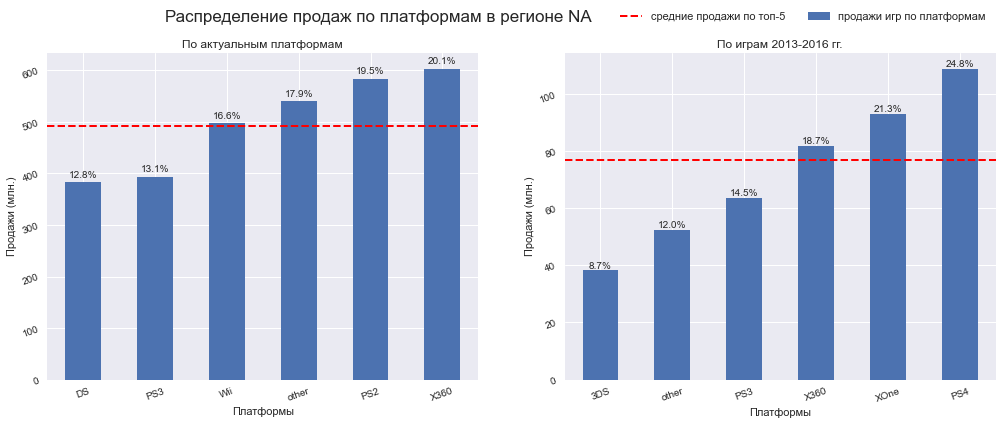

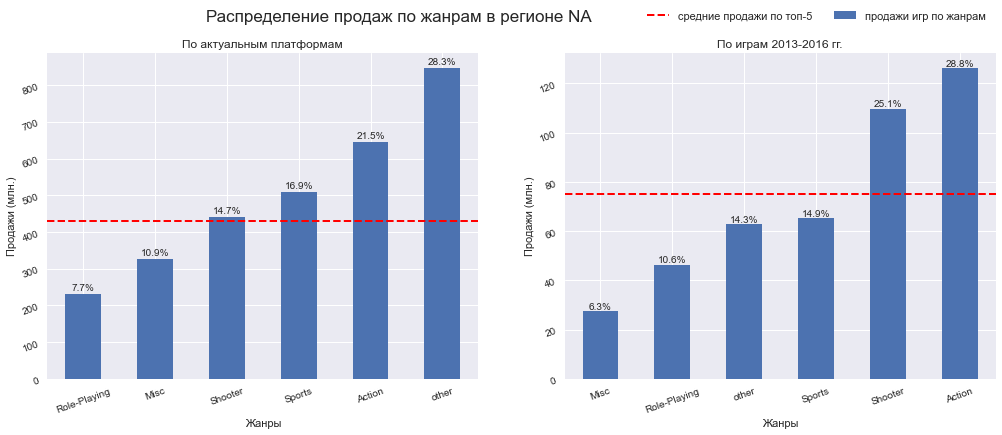

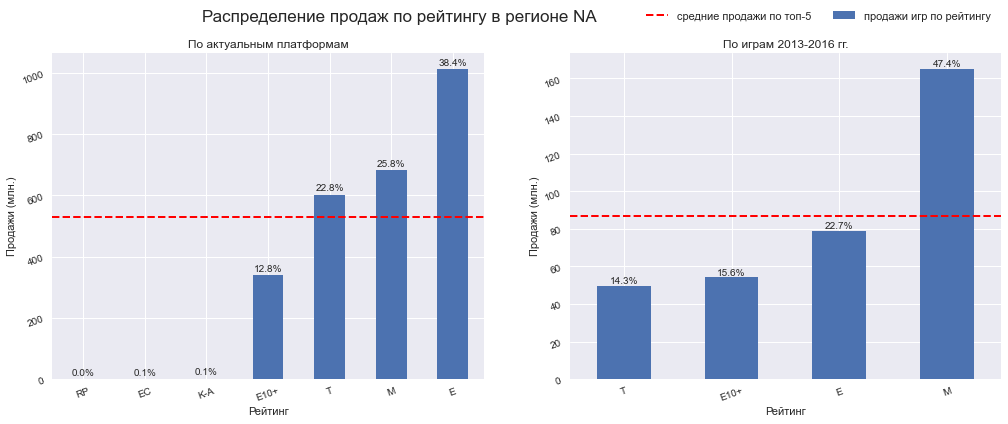

In [40]:
region_sales_visualisation('na_sales', 'NA')

По региону NA можно сделать следующие выводы:
1. Регион тяготеет к собственным игровым платформам: XOne и X360 занимают 2 и 3 места в продажах за последние 4 года, при этому нужно отметить, что отставание XOne от PS4 небольшое, а X360 вообще находится в завершающей фазе своего жизненного цикла. В более же длительной ретроспективе X360 на родном для себя рынке занимает первое место. Из выделенной пятерки наиболее перспективных с точки зрения продаж платформ в топ-5 по региону при использовании актуальных данных вошли три - PS4, XOne и 3DS. PC с WiiU не смогли конкурировать с популярными PS3 и X360, которые держат значительные доли даже на излете продаж.
2. Пятерка самых популярных жанров (action, shooter, sports, RPG и msic) за 15 лет осталась неизменной, но предпочтение аудитории сместилось в сторону более динамичных игр - экшены и шутеры вышли на первое место, прочие же жанры снизили свою совокупную долю вдвое.
3. За весь рассматриваемый период, за единичными исключениями, представлены игры, относящиеся к четырем возрастным рейтингам - E, E10+, T и M. Причем если брать данные по актуальным игровым продуктам, доминирует рейтинг M - остальные даже не пересекают линию средних по выборке продаж. При учете данных за более длительный временной промежуток становится видно, что детских игр с течением времени стали выпускать значительно меньше. Вероятно приничина кроется в их более низком потенциале продаж.

### EU

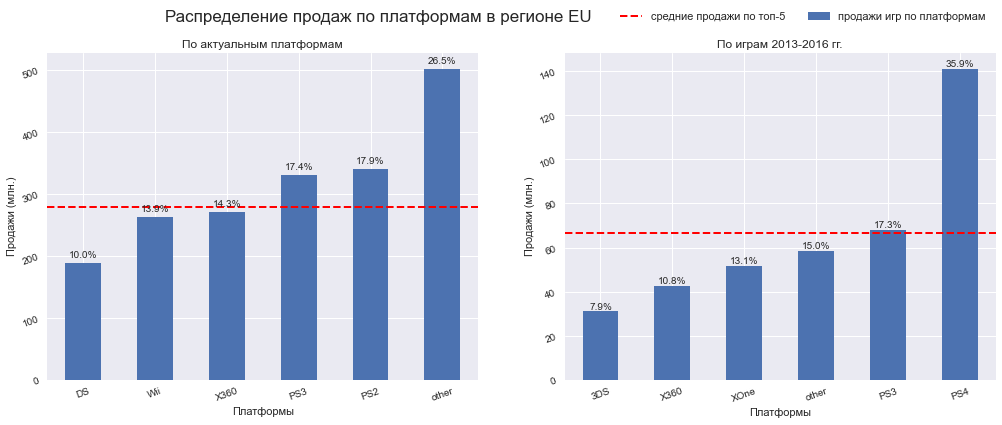

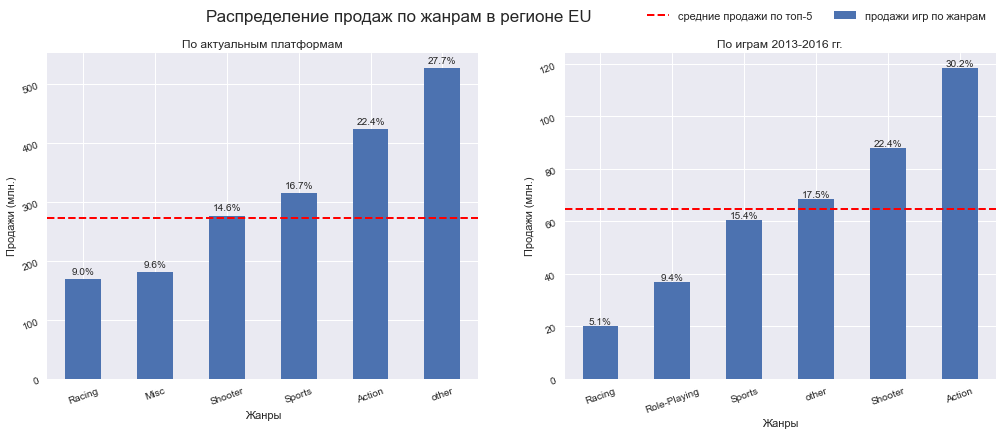

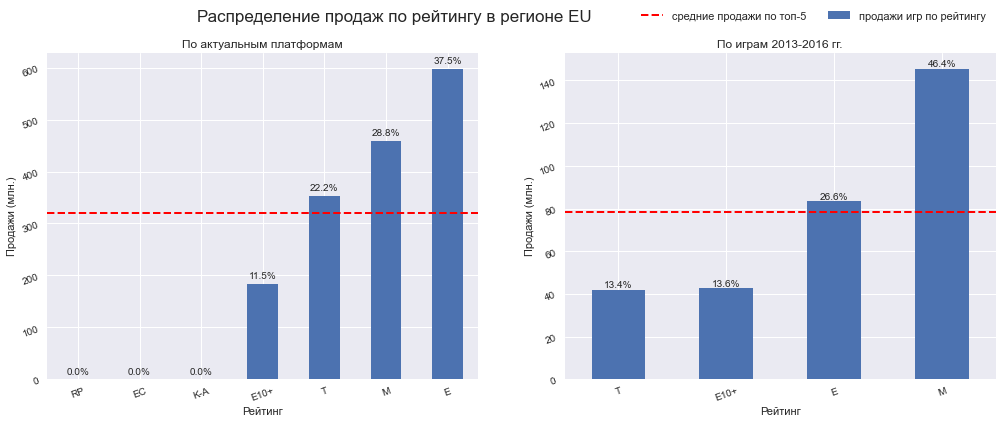

In [41]:
region_sales_visualisation('eu_sales', 'EU')

Что можно сказать про регион EU:
1. Если раньше регион тяготел к разннобразию и явно доминирующих платфор не было, то в последние годы он очевидно тяготеет к платформам Sony - PS4 очевидно главенствует на европейском рынке. При этом платформы microsoft также пользуются популярностью - если не группировать оставшиеся платформы в единую категорию, они идут сразу за PS4 и PS3.
2. Предпочитаемые жанры во многом аналогичны северной америке, за исключением появившихся в топ-5 гонок. Более разнообразное распределение по итогам последних 4 лет уступило динамичным жанрам - экшенам, шутерам и спортивным играм. Музыкальные игры в итоге разонравились европейцам и они перешли на гонки и в большей степени RPG.
3. Ситуация с рейтингами черезвычайно похожа на североамериканский рынок, лишь незначительно отличаются доли. Видимо тендеция к уменьшение доли детских игр за счет роста доли более продаваемого рейтинга M универсальна. Осталось сравнить с японским рынком.

В целом же, рынки северной америки и европы очень схожи, за исключением более теплого отношения к платформам PS в европе и некоторых флуктуаций в предпочитаемых жанрах.

### JP

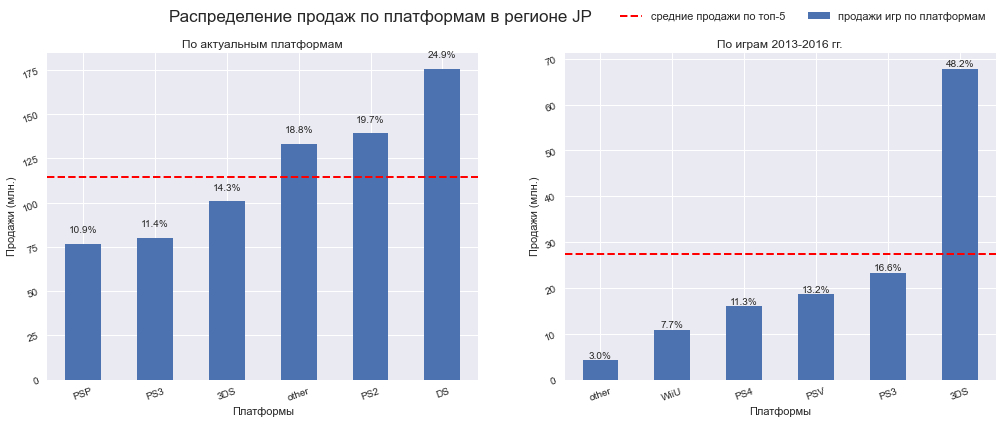

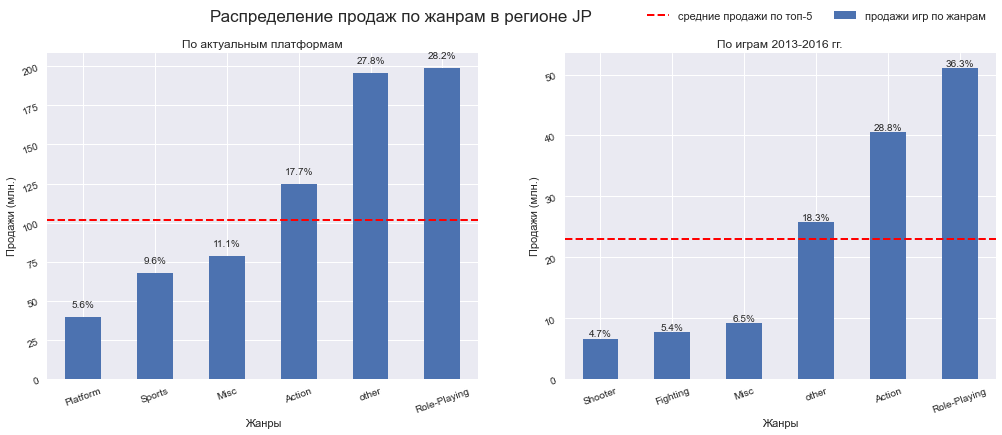

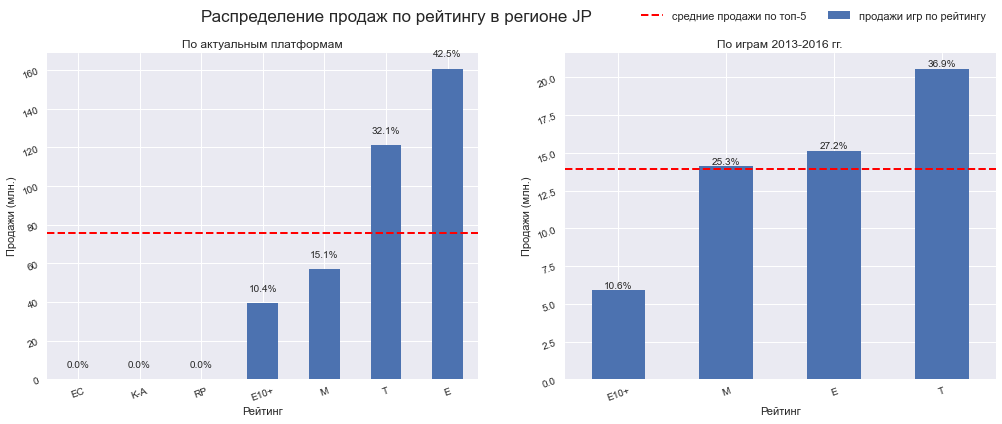

In [42]:
region_sales_visualisation('jp_sales', 'JP')

Регион JP:
1. Ожидаемо в топе "домашние" японские платформы. При этом можно выделить две интересные особенности. Во-первых, на рынке очевидно доминируют плафтормы Nintendo, которые на других рынках скромно замыкают топ-5. Во-вторых, в Японии популярны портативные консоли, и их популярность имеет растущий тренд - по данным за последние 4 года PSV держится на третьем месте, обогнав даже актуальную PS4 (являющуюся абсолютным лидером на европейском рынке).
2. Пятерка самых популярных жанров также сильно отличается. В Японии больше всего любят RPG, причем со временем популярность этого жанра только выросла. 2 и 3 место (без учета не вошедших в топ-5 жанров) также стабильно занимают экшены и музыкальные игры соотвественно. А вот 4 и 5 места с течением времени изменились - вместо спортивных игр и платформеров  последние 4 года продаются файтинги и шутеры. При этом заметно перетягивание наиболее популярными жанрами продаж на себя - по актуальным данным экшены и RPG занимают 2/3 всего японского рынка, тогда как все остальные жанры из топ-5 составляют 1/6 вместе взятые.
3. Распределение по возрастному рейтингу игр также сильно отличается. И если в более длительной ретроспективе разница с северной Америкой и Европой не так велика (рейтинги M и T, находящиеся на 2 и 3 местах расположены зеркально), то за последние годы разница уже существенна. Хотя увеличение доли игр для взрослых коснулось и японского рынка, процент игр с рейтингом М вырос с 15 до 25, оставшись на третьем месте. Доля рейтинга-аутсайдера (E10+) практически не изменилась. Зато рейтинг Т набрав всего 5% вышел на первое место, за счет сильного снижения доли рейтинга E, откатившегося на 2 место. Таким образом хотя количество игр для взрослых и стало больше в общей пропорции, 2/3 игр относится к категориям E и T. 

В целом, если североамериканский и европейский рынки похожи друг на друга, рынок Японии является уникальным, как по популярным платформам и жанрам, так и по возрастным рейтингам продающихся игр.

## Проверка гипотез

Выдвенем и проверим две гипотезы. 
1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.
2. Средние пользовательские рейтинги жанров Action и Sports разные.
Для обеих примем пороговое значение alpha (критический уровень статистической значимости) равным 5%.

In [43]:
alpha = .05

### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

**H_0 (нулевая гипотеза):** пользовательский рейтинг (user_score) игр платформы Xbox One = пользовательский рейтинг (user_score) игр платформы PC\
**H_a (двусторонняя альтернативная гипотеза):** пользовательский рейтинг (user_score) игр платформы Xbox One ≠ пользовательский рейтинг (user_score) игр платформы PC

Применим метод ttest_ind для проверки гипотезы о равенстве среднего двух генеральных совокупностей. Для этого передадим ему списки с пользовательскими рейтингами двух исследуемых платформ. Скорее всего обе выборки достаточно большие и вряд ли одинаковые по размеру, поэтому установим параметр `equal_var = False`. Тем не менее перед проведением теста посмотрим на размеры выборок.

In [44]:
print(df.query('platform == "XOne" and user_score != 0')['user_score'].shape[0])
df.query('platform == "PC" and user_score != 0')['user_score'].shape[0]

182


770

Размер достаточный, но сильно разный, останавливаемся на предложенных выше параметрах.

In [45]:
results = stats.ttest_ind(
    df.query('platform == "XOne" and user_score != 0')['user_score'].to_list(), 
    df.query('platform == "PC" and user_score != 0')['user_score'].to_list(),
    equal_var = False)

print('p-значение: {:.4f}'.format(results.pvalue))

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу, пользовательские рейтинги платформ Xbox One и PC разные')
else:
    print('Не получилось отвергнуть нулевую гипотезу, нельзя сказать, что рейтинги платформ Xbox One и PC разные')

p-значение: 0.0000
Отвергаем нулевую гипотезу, пользовательские рейтинги платформ Xbox One и PC разные


### Средние пользовательские рейтинги жанров Action и Sports разные.

**H_0 (нулевая гипотеза):** пользовательский рейтинг (user_score) игр жанра Action = пользовательский рейтинг (user_score) игр жанра Sports\
**H_a (двусторонняя альтернативная гипотеза):** пользовательский рейтинг (user_score) игр жанра Action ≠ пользовательский рейтинг (user_score) игр жанра Sports

Метод проверки полность идентичен предыдущей гипотезе.

In [46]:
print(df.query('genre == "Action" and user_score != 0')['user_score'].shape[0])
df.query('genre == "Sports" and user_score != 0')['user_score'].shape[0]

1830


1103

In [47]:
results = stats.ttest_ind(
    df.query('genre == "Action" and user_score != 0')['user_score'].to_list(), 
    df.query('genre == "Sports" and user_score != 0')['user_score'].to_list(),
    equal_var = False)

print('p-значение: {:.4f}'.format(results.pvalue))

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу, пользовательские рейтинги жанров Action и Sports разные')
else:
    print('Не получилось отвергнуть нулевую гипотезу, нельзя сказать, что рейтинги жанров Action и Sports разные')

p-значение: 0.1148
Не получилось отвергнуть нулевую гипотезу, нельзя сказать, что рейтинги жанров Action и Sports разные


## Вывод

При планировании рекламных кампаний стоит учитывать несколько ключевых факторов, оказывающих влияние на популярность игровых продуктов.
1. Во-первых, **игровая платформа**. В результате анализа продаж получилось выделить пять наиболее перспективных платформ, на которых стоит сконцентрировать внимание:
- PS4
- XOne
- 3DS
- WiiU
- PC

При планировании кампаний стоит учитывать факт итеративной смены поколений популярных игровых консолей и их типовой жизненный срок, составляющий около 9-10 лет, под конец которого продажи минимальны. Наиболее рационально делать ставку именно на актуальные консоли, находящиеся в диапазоне 2-6 лет жизненного цикла. PC хоть и является стабильной платформой, показатели продаж игр на нем, как правило, сильно хуже консольных, как по мертике количества продаж на выпущенную игру, так и по количесту продаж за год. Поэтому при работе с этой платформой стоит делать ставку на узнаваемые игровые тайтлы или уже имеющие определенный медийный ресурс проекты от знаменитых разработчиков. Консервативным сценарием можно назвать игры WiiU, которые показывают очень стабильные продажи - медиана схожа с самыми продающими PS4 и XOne, а 25% квартиль максимальный из всех перечисленных платформ.

2. Во-вторых, **жанр**. Самыми коммерчески успешными жанрами, на которые стоит обратить внимание - Shooter, Platform, Role-Playing, Sports	и Fighting. Также хорошо себя показывают гонки (Racing), особенно без привязки к целевым платформам. У остальных жанров количество продаваемых копий на одну игру ниже среднего показателя по индустрии. Несмотря на это не стоит забывать про Action - несмотря на посредственные средние показатели продаж на игру, этот жанр очень популярен и характерируется высоким разбросом значений продаж, внутри него есть продукты с очень хорошими продажами.


3. **Рейтинги игроков и критиков**. Очевидно, что благосклонно встреченные игроками и критиками игры с хорошими оценками наверняка будут лучше продаваться. Однако ориентироаться здесь в первую очередь стоит на оценки именно критиков - взаимосвязь между их оценками и продажами более сильная, причем высокие оценки критиков с большей вероятностью конвертируются в высокие продажи.


4. **Рынки**. По предоставленным данным выделяется три тынка - северная Америка (NA), Европа (EU) и Япония (JP), и каждый из них имеет свои особенности, которые необходимо учитывать. И если для северной Америки и Европы еще возможно использовать одни и теже маркетинговые стратегии и компании, т.к. они довольно похожи между собой, то рынок Японии отличается очень сильно по всем изученным метрикам. Напрмер, наиболее успешные в NA платформы продаются в JP очень плохо и наоборот. Аналогичная ситуация и с жанрами. 